# Duplicate of sampling.ipynb for doing repeated runs

## 0.1. Imports and load data

In [ ]:
import ase.io
import os
from pathlib import Path
import numpy as np
import importlib
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from mace import modules
from mace.data.atom_data_loader import AtomDataLoaderBuilder
from mace.testing import Tester
from mace.training import FreezeStrategy, NaiveStrategy, Trainer, initialise_autoencoder

import sampling_methods.descriptors as descriptors
import sampling_methods.selectors as selectors
import utils.training as training

importlib.reload(descriptors)
importlib.reload(selectors)
importlib.reload(training)

MAX_EPOCHS = 10
R_MAX = 5.0
BATCH_SIZE = 16
BASE_LR = 1.0e-3
TRANSFER_LR = 5.0e-4
DEVICE = torch.device("cpu")

# define wrapper classes
trainer = Trainer(
    max_epochs=MAX_EPOCHS, early_stopping=True, patience=15,
    restore_best=True, device=DEVICE, verbose=True,
)
data_builder = AtomDataLoaderBuilder(
    cutoff=R_MAX, energy_key="REF_energy", forces_key="REF_forces"
)
tester = Tester(device=DEVICE)
loss_fn = modules.InvariantsWeightedEnergyForcesNacsDipoleLoss(
    energy_weight=1.0, forces_weight=5.0, dipoles_weight=0.0,
    nacs_weight=0.0, socs_weight=0.0,
).to(DEVICE)


<module 'utils.training' from '/home/lim_yt/X-MACE-sampling/utils/training.py'>

In [4]:
ROOT_PATH = Path.cwd()
DATA_DIR = ROOT_PATH / "../data"

# dataset for training the base model, ie foundation/pre-trained model
BASE_XYZ = DATA_DIR / "A02_propene_grid_static.xyz"
BASE_N_GEOMETRIES = '500'  # number of geometries to use from the base dataset

# dataset for transfer learning
TRANSFER_XYZ = DATA_DIR / "casscf_44_propene_full.xyz"
TRANSFER_N_GEOMETRIES = '500' # number of geometries to use from the transfer dataset

OUTPUT_DIR = ROOT_PATH / "../outputs"

base_atoms_list = ase.io.read(BASE_XYZ, index=f":{BASE_N_GEOMETRIES}")
transfer_atoms_list = ase.io.read(TRANSFER_XYZ, index=f":{TRANSFER_N_GEOMETRIES}")

print("base_atoms_list length:", len(base_atoms_list))
print("transfer_atoms_list length:", len(transfer_atoms_list))


base_atoms_list length: 500
transfer_atoms_list length: 500


## 0.2. Split into test, train, valid sets

In [ ]:
# get bond lengths and dihedrals
# tested on propene only

desc_matrix = []
bond_lengths = []
dihedrals = []

for atom in base_atoms_list:
    bond_length = descriptors.get_descriptor("bond_lengths",atom)[0]
    dihedral = descriptors.get_descriptor("dihedral",atom)[0]
    
    bond_lengths.append(bond_length)
    dihedrals.append(dihedral)
    desc_matrix.append([bond_length, dihedral])

desc_matrix = np.asarray(desc_matrix)

# extract test set
# the same test set is removed from both base and transfer datasets

TEST_SET_FRACTION = 0.1
TEST_SET_SIZE = int(np.floor(int(BASE_N_GEOMETRIES) * TEST_SET_FRACTION))

test_set_idx = selectors.get_selector("uniform_grid", desc_matrix, TEST_SET_SIZE)
base_test_set = [base_atoms_list[i] for i in test_set_idx]
transfer_test_set = [transfer_atoms_list[i] for i in test_set_idx]
print("Test set size:", len(base_test_set))

# remaining geometries are for training and validation
train_valid_set_idx = np.setdiff1d(np.arange(len(transfer_atoms_list)), test_set_idx)
base_train_valid_set = [base_atoms_list[i] for i in train_valid_set_idx]
transfer_train_valid_set = [transfer_atoms_list[i] for i in train_valid_set_idx]

# split remaining geometries into train and valid sets
# the same for both base and transfer datasets

SEED = 42 # set as int to get the same split every time
VALID_SET_FRACTION = 0.2 # as a fraction of the total dataset

train_set_idx, valid_set_idx = train_test_split(
    train_valid_set_idx, test_size=VALID_SET_FRACTION/(1-TEST_SET_FRACTION), random_state=SEED, shuffle=True
)

base_train_set = [base_atoms_list[i] for i in train_set_idx]
print("\nBase train set size:", len(base_train_set))
base_valid_set = [base_atoms_list[i] for i in valid_set_idx]
print("Base valid set size:", len(base_valid_set))

transfer_train_set = [transfer_atoms_list[i] for i in train_set_idx]
print("\nFull high-fidelity train set size:", len(transfer_train_set))
transfer_valid_set = [transfer_atoms_list[i] for i in valid_set_idx]
print("Full high-fidelity valid set size:", len(transfer_valid_set))


Number of unique bond lengths: 41
Number of unique dihedral angles: 90


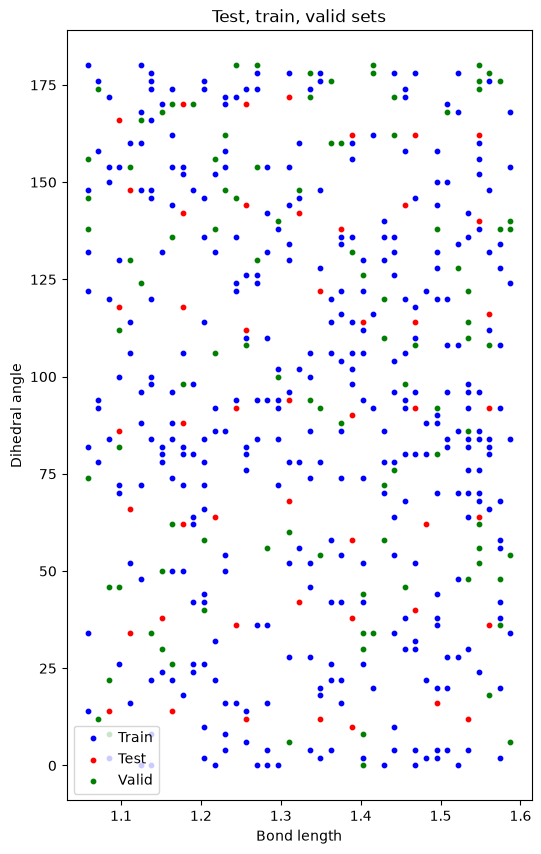

In [8]:
# visualise
plt.figure(figsize=(6, 10))  

plt.scatter([bond_lengths[i] for i in train_set_idx],
            [dihedrals[i] for i in train_set_idx], 
            color='blue', marker='o', s=10, label='Train')

plt.scatter([bond_lengths[i] for i in test_set_idx], 
            [dihedrals[i] for i in test_set_idx], 
            color='red', marker='o', s=10, label='Test')

plt.scatter([bond_lengths[i] for i in valid_set_idx], 
            [dihedrals[i] for i in valid_set_idx], 
            color='green', marker='o', s=10, label='Valid')

plt.title("Test, train, valid sets")
plt.xlabel("Bond length")
plt.ylabel("Dihedral angle")
plt.legend()

plt.show()

## 0.3. Train base model



In [9]:
base_train_loader = data_builder.load(
    base_train_set, batch_size=BATCH_SIZE, shuffle=True
)
base_valid_loader = data_builder.load(
    base_valid_set, batch_size=BATCH_SIZE, shuffle=False
)
base_test_loader = data_builder.load(
    base_test_set, batch_size=BATCH_SIZE, shuffle=False
)
torch.manual_seed(SEED)

base_model = initialise_autoencoder(data_builder.get_metadata(), preset="lightweight")
base_optimizer = torch.optim.Adam(base_model.parameters(), lr=BASE_LR)

base_model, base_history = trainer.train_model(
    base_model, base_train_loader, base_valid_loader, base_optimizer, loss_fn
)

tester.run_test(base_model, base_test_loader)
base_energy_mae = tester.get_energy_mae()
{"best_epoch": base_history["best_epoch"], "test_energy_mae_ev": base_energy_mae}


/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3

Epoch 001 | train_loss=112.202106 | valid_loss=131.505759
Epoch 002 | train_loss=100.455847 | valid_loss=124.357864
Epoch 003 | train_loss=76.450234 | valid_loss=54.080552
Epoch 004 | train_loss=41.250764 | valid_loss=35.191094
Epoch 005 | train_loss=30.699862 | valid_loss=28.692574
Epoch 006 | train_loss=28.165526 | valid_loss=27.144892
Epoch 007 | train_loss=26.770702 | valid_loss=26.186961
Epoch 008 | train_loss=25.932211 | valid_loss=24.645659
Epoch 009 | train_loss=25.173279 | valid_loss=24.603856
Epoch 010 | train_loss=24.889473 | valid_loss=23.767618


{'best_epoch': 10, 'test_energy_mae_ev': 1.416432499885559}

In [ ]:
# save model
base_model_filename = "base_model_propene_500_geometries_for_pca_testing.pt"
base_model_save_path = OUTPUT_DIR / "base_models" / base_model_filename
torch.save(base_model, base_model_save_path)
print(f"Base model saved to {base_model_save_path}")


Base model saved to /home/lim_yt/X-MACE-sampling/notebooks/../outputs/base_models/base_model_propene_500_geometries_for_pca_testing.pt


## 1. Choose descriptor

In [ ]:
DESCRIPTOR_TYPE = ["bond_lengths", "bond_angles", "dihedral", "energies", "encoded_energies", "soap", "acsf", "mbtr"]
DESCRIPTOR = DESCRIPTOR_TYPE[7]  # choose the descriptor type to use

base_encoder = base_model.perm_encoder

# matrix of descriptors for each geometry
# sampling is done on base dataset, out of the training pool only
# ie test and valid sets are already removed
desc_matrix = []
for atom in base_train_set:
    desc_matrix.append(descriptors.get_descriptor(DESCRIPTOR,atom,base_encoder))
desc_matrix = np.asarray(desc_matrix)

# n*m, where n is the number of geometries and m is the dimension of the descriptor
# eg if we use bond_lengths and propene, m=2 because there's 2 CC bonds in propene
print("desc_matrix shape:", desc_matrix.shape)
print("desc_matrix unique shape:", np.unique(desc_matrix, axis=0).shape)
print("desc_matrix:\n", desc_matrix)


/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/site-packages/dscribe/core/system.py:96: FutureWarning: Please use atoms.calc
  calculator=atoms.get_calculator(),


desc_matrix shape: (400, 765)
desc_matrix unique shape: (400, 765)
desc_matrix:
 [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [ ]:
# run this to use latent space as descriptor

from mace.testing import extract_latent_space

base_train_loader_unshuffle = data_builder.load(
    base_train_set, batch_size=BATCH_SIZE, shuffle=False
)
latent_space = extract_latent_space(
    base_model, base_train_loader_unshuffle, device=DEVICE
)

desc_matrix = latent_space
print("desc_matrix shape:", desc_matrix.shape)
print("desc_matrix unique shape:", np.unique(desc_matrix, axis=0).shape)
print("desc_matrix:\n", desc_matrix)

desc_matrix shape: (400, 16)
desc_matrix unique shape: (400, 16)
desc_matrix:
 [[-1.5216693   0.13421759 -0.77837443 ... -1.3956807   3.1393943
   1.5304707 ]
 [-1.523548    0.1332658  -0.7784626  ... -1.3935603   3.134028
   1.5284303 ]
 [-1.5731269   0.22831844 -0.84196955 ... -1.3283169   3.1342967
   1.4212309 ]
 ...
 [-1.5251999   0.13785027 -0.7811985  ... -1.3908033   3.132894
   1.5228235 ]
 [-1.6004163   0.26048136 -0.86730736 ... -1.2925972   3.1294158
   1.3797204 ]
 [-1.5304098   0.14212975 -0.7850682  ... -1.3853344   3.1289387
   1.515557  ]]


In [ ]:
# optional dimensionality reduction using PCA

PCA_DIMENSIONS = 3

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

desc_matrix_scaled = StandardScaler().fit_transform(desc_matrix)

pca = PCA(n_components=PCA_DIMENSIONS)
desc_matrix = pca.fit_transform(desc_matrix_scaled)

print("desc_matrix shape:", desc_matrix.shape)
print("desc_matrix unique shape:", np.unique(desc_matrix, axis=0).shape)
print("desc_matrix:\n", desc_matrix)

desc_matrix shape: (500, 3)
desc_matrix unique shape: (500, 3)
desc_matrix:
 [[ 25.66290073  -7.5435525    3.57461524]
 [-17.68889132  -1.97186744 -11.88806588]
 [ -9.68128667   8.30790249  11.93837659]
 ...
 [ -4.73528134  13.40840203  -1.75137886]
 [ -0.93051678  -9.05129291  -4.19616038]
 [ -3.10642808 -11.28432425  -3.91061191]]


## 2. Choose selector

In [11]:
SELECTOR_TYPE = ["random_sampling", "farthest_point_sampling", "k_means_clustering", "birch", "dbscan", "dbscan_weighted"]
SELECTOR = SELECTOR_TYPE[0]  # choose the selector type to use

# number of samples to select from the transfer dataset
N_SAMPLES = 100

# select samples based on the descriptor matrix
sampled_idx = selectors.get_selector(SELECTOR, desc_matrix, N_SAMPLES, n_clusters=5)

# sample atoms out of transfer dataset
sampled_atoms = [transfer_train_set[i] for i in sampled_idx]

print("sampled indices:\n", sampled_idx)
print("number sampled:", len(sampled_idx))


sampled indices:
 [234 342 221  56 196 271 286 274 279  67 310  17 217 150  84 193  57 159
  95 293 205 297 145  39 214 176 339 181  16  52 252  46 321 106 211 219
 323 308 273 327 267 147 194 130 220  27 341  23 162 146 278  65  42 223
 296 167 291 108 228 329  62 111 109 199 280  79 242 137 200 138 348 257
 335  12 325  70 112 222 258  75  99  36 299 290   7 101  49  64 320 208
  31 100 283 260 116 163 294  15 179 262]
number sampled: 100


## 3. Repeated runs of training transfer model

In [12]:
best_epochs = []
energy_maes = []


In [13]:
N_REPEATS = 10

# load train, valid, test sets
transfer_train_loader = data_builder.load(
    sampled_atoms, batch_size=BATCH_SIZE, shuffle=True
)
full_valid_loader = data_builder.load(
    transfer_valid_set, batch_size=BATCH_SIZE, shuffle=False
)
full_test_loader = data_builder.load(
    transfer_test_set, batch_size=BATCH_SIZE, shuffle=False
)

for _ in range(N_REPEATS):

    # do the training
    transfer_model = NaiveStrategy().apply(base_model)
    transfer_optimizer = torch.optim.Adam(transfer_model.parameters(), lr=TRANSFER_LR)

    torch.manual_seed(SEED)

    transfer_model, transfer_history = trainer.train_model(
        transfer_model, transfer_train_loader, full_valid_loader, transfer_optimizer, loss_fn
    )

    # do the testing
    tester.run_test(transfer_model, full_test_loader)
    transfer_energy_mae = tester.get_energy_mae()
    {"best_epoch": transfer_history["best_epoch"], "test_energy_mae_ev": transfer_energy_mae}

    best_epochs.append(transfer_history["best_epoch"])
    energy_maes.append(transfer_energy_mae)
    

Epoch 001 | train_loss=19.786582 | valid_loss=16.654447
Epoch 002 | train_loss=13.171552 | valid_loss=11.271207
Epoch 003 | train_loss=9.864867 | valid_loss=10.538854
Epoch 004 | train_loss=9.370027 | valid_loss=10.514385
Epoch 005 | train_loss=9.580555 | valid_loss=9.825947
Epoch 006 | train_loss=9.112462 | valid_loss=9.564742
Epoch 007 | train_loss=9.513504 | valid_loss=10.461883
Epoch 008 | train_loss=9.204791 | valid_loss=9.597907
Epoch 009 | train_loss=9.400089 | valid_loss=9.642349
Epoch 010 | train_loss=9.153155 | valid_loss=10.744678
Epoch 001 | train_loss=19.786582 | valid_loss=16.654447
Epoch 002 | train_loss=13.171552 | valid_loss=11.271207
Epoch 003 | train_loss=9.864867 | valid_loss=10.538854
Epoch 004 | train_loss=9.370027 | valid_loss=10.514385
Epoch 005 | train_loss=9.580555 | valid_loss=9.825947
Epoch 006 | train_loss=9.112462 | valid_loss=9.564742
Epoch 007 | train_loss=9.513504 | valid_loss=10.461883
Epoch 008 | train_loss=9.204791 | valid_loss=9.597907
Epoch 009 | t

## 4. Plot

--- Best epochs ---
10
Mean: 6.0
Population stdev: 0.0
Sample stdev: 0.0


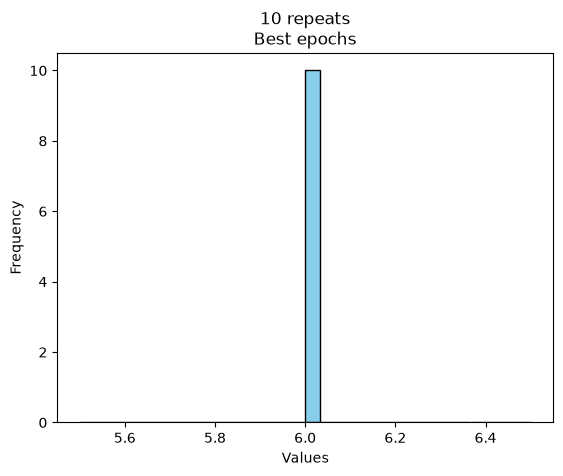

--- Energy MAEs ---
10
Mean: 0.7116234302520752
Population stdev: 0.0
Sample stdev: 0.0


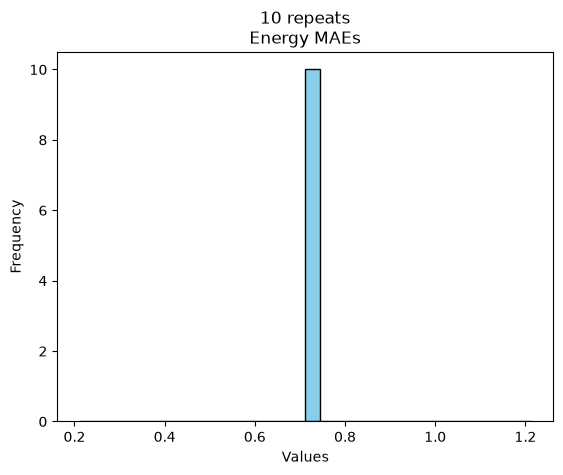

In [14]:
import matplotlib.pyplot as plt

print("--- Best epochs ---")
print(len(best_epochs))
print("Mean:", np.mean(best_epochs))
print("Population stdev:", np.std(best_epochs))
print("Sample stdev:", np.std(best_epochs, ddof=1))

plt.hist(best_epochs, bins=30, color='skyblue', edgecolor='black')

plt.title(f'{N_REPEATS} repeats\nBest epochs')
plt.xlabel('Values')
plt.ylabel('Frequency')

plt.show()

print("--- Energy MAEs ---")
print(len(energy_maes))
print("Mean:", np.mean(energy_maes))
print("Population stdev:", np.std(energy_maes))
print("Sample stdev:", np.std(energy_maes, ddof=1))

plt.hist(energy_maes, bins=30, color='skyblue', edgecolor='black')

plt.title(f'{N_REPEATS} repeats\nEnergy MAEs')
plt.xlabel('Values')
plt.ylabel('Frequency')

plt.show()
